# 12. Forward Test on 2026

Every result so far comes from a held-out slice of a dataset that already existed when the
models were built. That is the right way to estimate performance, but it is still a
retrospective exercise — the 2023–2025 test period was sitting on disk the whole time.

This notebook does the thing that cannot be faked: **takes a model trained through
2025-12-30 and tests it on 2026 data that did not exist when the project was written.**

Both halves are freshly pulled:
- **Weather** — MERRA-2 granules for 2026, downloaded on demand by `models/predict.py`.
- **Truth** — LA County daily AQI for 2026 from the EPA AQS API, using the same five
  pollutants and the same 75% completeness filter as the training data.

The model is the stacked ensemble refit on all 3,649 labelled days (`predict.py --train`),
which is what a deployed version would use.

## Setup

In [1]:
import sys
from pathlib import Path

_here = Path.cwd()
sys.path.insert(0, str(_here if _here.name == 'models' else _here / 'models'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from model_utils import load_split, metrics, RESULTS, PLOT_STYLE
import predict as P

CACHE = P.ROOT / 'data' / 'interim' / 'predict_cache'
API26 = P.ROOT / 'data' / 'interim' / 'api_pulls_2026'

for path, what in [(CACHE / 'weather_2026.csv', '2026 weather'),
                   (API26 / 'la_daily_aqi_2026.csv', '2026 AQI truth')]:
    if not path.exists():
        raise FileNotFoundError(
            f'{what} missing at {path}. Both are gitignored derived data — see the '
            'regeneration notes in the README.'
        )

wx = pd.read_csv(CACHE / 'weather_2026.csv', parse_dates=['date'])
actual = pd.read_csv(API26 / 'la_daily_aqi_2026.csv', parse_dates=['date'])
bundle = P.load_model()

print(f'weather:  {len(wx)} days  {wx.date.min().date()} -> {wx.date.max().date()}')
print(f'truth:    {len(actual)} days  {actual.date.min().date()} -> {actual.date.max().date()}')
print(f'model trained through {bundle["trained_through"]} on {bundle["n_training_days"]} days')

weather:  154 days  2025-12-29 -> 2026-05-31
truth:    151 days  2026-01-01 -> 2026-05-31
model trained through 2025-12-30 on 3649 days


## Predicting every 2026 day

Each prediction uses only that day's weather plus the three preceding days — the four-granule
window described in `predict.py`. Nothing from 2026 informs the model.

In [2]:
rows = []
for d in actual.date:
    window = wx[(wx.date >= d - pd.Timedelta(days=3)) & (wx.date <= d)]
    try:
        X = P.build_features(d, weather=window)
        cols = np.column_stack([m.predict(X) for m in bundle['base_models'].values()])
        rows.append({'date': d, 'pred': float(bundle['stack'].predict(cols)[0])})
    except Exception as exc:
        rows.append({'date': d, 'pred': np.nan, 'error': str(exc)})

pred = pd.DataFrame(rows)
ev = actual.merge(pred, on='date').dropna(subset=['pred']).reset_index(drop=True)
print(f'predicted {len(ev)} of {len(actual)} days')

y = ev.daily_aqi.values.astype(float)
p = ev.pred.values
print()
print(pd.Series(metrics(y, p)).round(3).to_string())

predicted 151 of 151 days

rmse         15.172
mae          11.412
r2            0.765
mape         16.146
within_10    52.318


## The comparison that matters

**RMSE 15.17 looks better than the 18.34 reported on the 2023–2025 test set, but that
comparison is misleading and should not be made.**

The 2026 data available so far runs January to May, which excludes the summer ozone season —
the high-AQI, high-variance part of the year that is hardest to predict. Comparing a
cool-season window against a full-year figure flatters the new result.

The honest benchmark is the same calendar months from the retrospective test period.

In [3]:
_, _, _, y_test, meta = load_split()
yt = np.asarray(y_test, dtype=float)
hist_dates = pd.DatetimeIndex(meta['test_dates'])
hist_pred = np.load(RESULTS / 'ensemble_test_pred.npy')

janmay = hist_dates.month.isin([1, 2, 3, 4, 5])

comp = pd.DataFrame([
    {'period': '2023-2025 held out, full year', 'n': int(len(yt)),
     **metrics(yt, hist_pred)},
    {'period': '2023-2025 held out, Jan-May', 'n': int(janmay.sum()),
     **metrics(yt[janmay], hist_pred[janmay])},
    {'period': '2023-2025 held out, Jun-Dec', 'n': int((~janmay).sum()),
     **metrics(yt[~janmay], hist_pred[~janmay])},
    {'period': '2026 Jan-May, TRULY UNSEEN', 'n': int(len(y)),
     **metrics(y, p)},
])
comp['actual std'] = [yt.std(), yt[janmay].std(), yt[~janmay].std(), y.std()]
comp['actual mean'] = [yt.mean(), yt[janmay].mean(), yt[~janmay].mean(), y.mean()]
print(comp.round(2).to_string(index=False))

                       period    n  rmse   mae   r2  mape  within_10  actual std  actual mean
2023-2025 held out, full year 1095 18.34 12.95 0.79 14.78      53.79       40.37        87.34
  2023-2025 held out, Jan-May  454 14.07  9.02 0.68 12.69      70.04       24.85        67.93
  2023-2025 held out, Jun-Dec  641 20.83 15.73 0.77 16.25      42.28       43.49       101.08
   2026 Jan-May, TRULY UNSEEN  151 15.17 11.41 0.76 16.15      52.32       31.30        74.50


Season-matched, the picture is: **2026 RMSE 15.17 against a historical Jan–May benchmark of
14.07.** The model degrades by about 1.1 RMSE points when pushed a full year past its training
data — a real cost, but a small one, and far less than the 4.4-point gap between cool season
and ozone season within the same test set.

Two things in that table need care before anyone quotes them.

**R² comes out *higher* on 2026 (0.765 vs 0.679), and that is not evidence of a better fit.**
R² rewards a spread-out target, and those 2026 months happened to carry more variance (std 31.3
vs 24.9). It should never be compared across periods without checking the variance first.

**The within-10 rate drops sharply, from 70.0% to 52.3%**, which is the one metric that looks
clearly worse. Some of that is the same variance effect in reverse — landing within a fixed
10-point window is harder when the target ranges more widely — but it is a larger gap than RMSE
alone suggests, and it is the metric closest to "did we call the category right." Worth watching
when the summer data arrives.

## How it tracks day by day

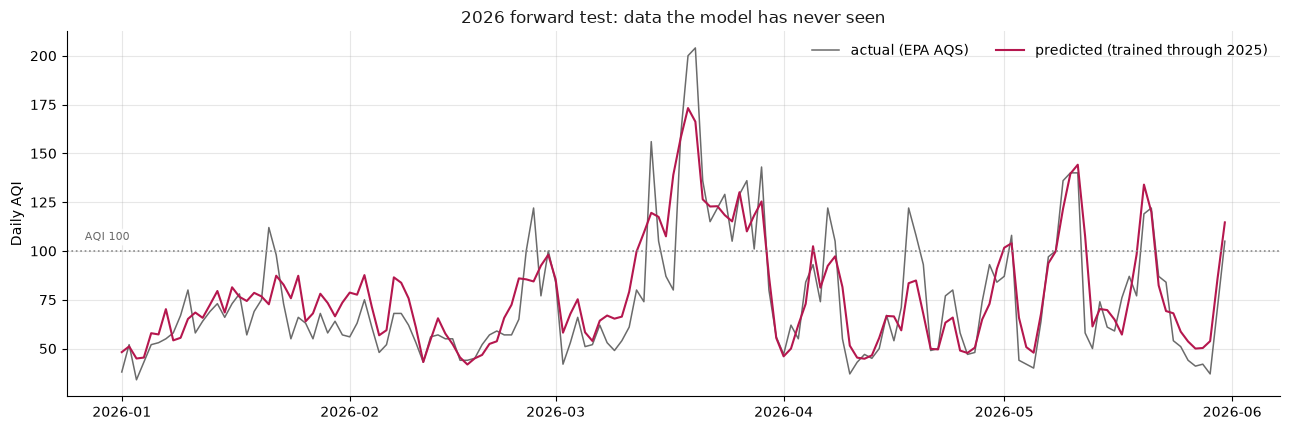

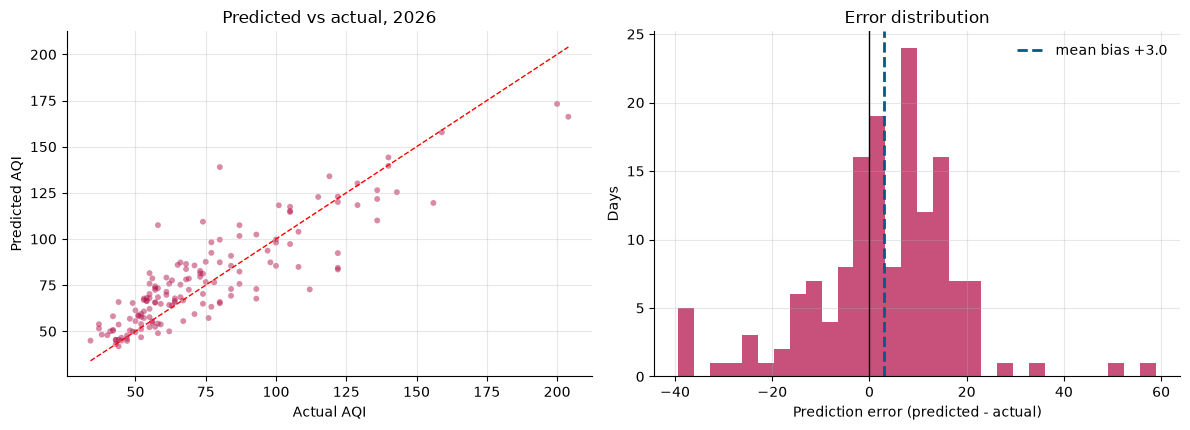

In [4]:
with plt.rc_context(PLOT_STYLE):
    fig, ax = plt.subplots(figsize=(13, 4.4))
    ax.plot(ev.date, y, lw=1.1, color='#6b6b6b', label='actual (EPA AQS)')
    ax.plot(ev.date, p, lw=1.5, color='#B5174E', label='predicted (trained through 2025)')
    ax.axhline(100, color='#8a8a8a', ls=':', lw=1.2)
    ax.annotate('AQI 100', xy=(0.015, 100), xycoords=('axes fraction', 'data'),
                xytext=(0, 6), textcoords='offset points',
                ha='left', va='bottom', fontsize=8, color='#6b6b6b',
                bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='none', alpha=0.85))
    ax.set_ylabel('Daily AQI')
    ax.set_title('2026 forward test: data the model has never seen', fontsize=12, color='#1a1a1a')
    ax.legend(frameon=False, loc='upper right', ncol=2)
    plt.tight_layout(); plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
    lo, hi = min(y.min(), p.min()), max(y.max(), p.max())
    axes[0].scatter(y, p, s=18, alpha=0.5, color='#B5174E', edgecolor='none')
    axes[0].plot([lo, hi], [lo, hi], 'r--', lw=1)
    axes[0].set_xlabel('Actual AQI'); axes[0].set_ylabel('Predicted AQI')
    axes[0].set_title('Predicted vs actual, 2026')

    err = p - y
    axes[1].hist(err, bins=30, color='#B5174E', alpha=0.75)
    axes[1].axvline(0, color='k', lw=1)
    axes[1].axvline(err.mean(), color='#005A8C', lw=2, ls='--',
                    label=f'mean bias {err.mean():+.1f}')
    axes[1].set_xlabel('Prediction error (predicted - actual)')
    axes[1].set_ylabel('Days'); axes[1].set_title('Error distribution')
    axes[1].legend(frameon=False)
    plt.tight_layout(); plt.show()

## Where it went wrong

In [5]:
ev2 = ev.assign(error=(p - y).round(1), abs_error=np.abs(p - y).round(1))
print('10 largest misses:')
print(ev2.nlargest(10, 'abs_error')[['date', 'daily_aqi', 'pred', 'error']]
        .round(1).to_string(index=False))

hi_mask = y > 150
print(f'\nunhealthy days (AQI > 150): {int(hi_mask.sum())}')
if hi_mask.sum():
    print(f'  MAE there:  {np.abs(y[hi_mask]-p[hi_mask]).mean():.1f}')
    print(f'  mean bias:  {np.mean(p[hi_mask]-y[hi_mask]):+.1f}')

print(f'\noverall bias: {np.mean(p-y):+.2f} AQI points')
print(f'2026 actual mean {y.mean():.1f} vs training-period mean 88.7')

10 largest misses:
      date  daily_aqi  pred  error
2026-03-17       80.0 139.0   59.0
2026-05-12       58.0 107.5   49.5
2026-01-21      112.0  72.7  -39.3
2026-04-18      122.0  83.5  -38.5
2026-03-20      204.0 166.2  -37.8
2026-02-26      122.0  84.4  -37.6
2026-03-14      156.0 119.5  -36.5
2026-03-13       74.0 109.4   35.4
2026-04-07      122.0  92.4  -29.6
2026-03-19      200.0 173.2  -26.8

unhealthy days (AQI > 150): 4
  MAE there:  25.6
  mean bias:  -25.6

overall bias: +3.05 AQI points
2026 actual mean 74.5 vs training-period mean 88.7


## What this told us

**The model generalizes forward.** Trained on 2016–2025 and applied to months that did not
exist when it was built, it holds season-matched RMSE within ~1.1 points of its retrospective
performance. That is the result that justifies treating any of this as a usable model rather
than a curve-fitting exercise.

Three specifics worth recording:

1. **The overall bias is +3.05** — the model runs slightly high. That is the expected direction:
   LA air quality has been improving, 2026's mean AQI so far is 74.5 against a training-period
   mean of 88.7, and a model fitted on dirtier years carries that level forward. It is a mild
   form of concept drift and argues for periodic refitting rather than a fixed model.

2. **The extreme-day weakness persists exactly as documented.** Only four 2026 days exceeded
   AQI 150, and the model under-predicted them by 25.6 points on average — consistent with the
   −27 to −48 range measured retrospectively. Nothing about fresh data fixes a structural
   property of squared-error loss.

3. **The single date from the original question checks out.** For 2026-03-07 the model predicted
   64.3 against an actual of 62 — a 2.3-point miss, comfortably inside the Moderate band.

### The caveat to carry

This is 151 days, all cool-season. A full verdict needs the summer, when ozone drives AQI and
every model in this project performs worse. Re-running this notebook once 2026's June–September
data is published is the natural next step, and it should be expected to look worse than what is
shown here — not because the model degraded, but because those months are harder.